# 02 — Features

Build a one-row-per-activity feature matrix `model_table.parquet` from the artifacts of `01_ingest.ipynb`. Sections:

1. **Stream aggregates** — per-activity stats from per-second sensor data (HR, pace, grade, cadence, time-in-zone, GAP proxy).
2. **Training-load** — rolling and EWMA features over the activity history (always shifted by one day to prevent same-day leakage).
3. **Summary** — fields lifted from `activities.csv` and the athlete `profile.csv`.
4. Join, clean, write `data/processed/model_table.parquet`.

Target: `relative_effort` (Strava Relative Effort).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
assert PROJECT_ROOT.name == "Project"

REPO_ROOT = PROJECT_ROOT.parent
EXPORT_ROOT = REPO_ROOT.parent / "Strava-Export"
DATA_DIR = PROJECT_ROOT / "data"
(DATA_DIR / "interim").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "processed").mkdir(parents=True, exist_ok=True)

RACE_DATE = pd.Timestamp("2026-04-12", tz="UTC")

activities = pd.read_parquet(DATA_DIR / "raw" / "activities_raw.parquet")
streams = pd.read_parquet(DATA_DIR / "streams" / "streams.parquet")
print("activities:", activities.shape, "  streams:", streams.shape)

activities: (482, 98)   streams: (1348656, 13)


## 2.1 Per-activity stream aggregates

HR, pace, grade, cadence stats; time-in-zone using observed HRmax (max of stream HR and 195); a Minetti-style grade-adjusted speed proxy as a fallback when the summary `Average Grade Adjusted Pace` is missing.

In [2]:
# HRmax estimate from the athlete's own data (cap at >=195 to avoid degenerate zones from low-coverage runs)
hr_max = float(max(streams["hr_bpm"].max(), 195))
print("HRmax used for zoning:", hr_max)

# Per-step grade and Minetti-style GAP speed
streams = streams.sort_values(["activity_id", "elapsed_s"]).reset_index(drop=True)
g_dele = streams.groupby("activity_id")["ele_m"].diff()
g_ddist = streams.groupby("activity_id")["dist_m"].diff()
streams["grade"] = (g_dele / g_ddist).where(g_ddist > 0.5).clip(-0.45, 0.45).astype("float32")
streams["gap_speed"] = (
    streams["speed_mps"] * (1 + 3.3 * streams["grade"] + 32.5 * streams["grade"] ** 2)
).astype("float32")

HRmax used for zoning: 210.0


In [3]:
def hr_zone(hr: pd.Series, hr_max: float) -> pd.Series:
    pct = hr / hr_max
    z = pd.Series(np.nan, index=hr.index, dtype="float32")
    z = z.mask(pct < 0.6, 1)
    z = z.mask((pct >= 0.6) & (pct < 0.7), 2)
    z = z.mask((pct >= 0.7) & (pct < 0.8), 3)
    z = z.mask((pct >= 0.8) & (pct < 0.9), 4)
    z = z.mask(pct >= 0.9, 5)
    return z

streams["hr_zone"] = hr_zone(streams["hr_bpm"], hr_max)


def aggregate_streams(g: pd.DataFrame) -> pd.Series:
    moving = g[g["speed_mps"] > 0.5]
    out = {
        "n_stream_rows": len(g),
        "mean_hr": g["hr_bpm"].mean(),
        "std_hr": g["hr_bpm"].std(),
        "p50_hr": g["hr_bpm"].median(),
        "p90_hr": g["hr_bpm"].quantile(0.9),
        "p95_hr": g["hr_bpm"].quantile(0.95),
        "max_hr_stream": g["hr_bpm"].max(),
        "mean_speed_mps": moving["speed_mps"].mean(),
        "p50_speed_mps": moving["speed_mps"].median(),
        "p90_speed_mps": moving["speed_mps"].quantile(0.9),
        "std_speed_mps": moving["speed_mps"].std(),
        "mean_grade": g["grade"].mean(),
        "p10_grade": g["grade"].quantile(0.1),
        "p90_grade": g["grade"].quantile(0.9),
        "abs_grade_mean": g["grade"].abs().mean(),
        "mean_cadence": g["cadence_rpm"].mean(),
        "std_cadence": g["cadence_rpm"].std(),
        "mean_gap_speed": moving["gap_speed"].mean(),
    }
    total = g["hr_zone"].notna().sum()
    if total > 0:
        for z in (1, 2, 3, 4, 5):
            out[f"frac_z{z}"] = (g["hr_zone"] == z).sum() / total
    else:
        for z in (1, 2, 3, 4, 5):
            out[f"frac_z{z}"] = np.nan
    return pd.Series(out)


stream_aggs = (
    streams.groupby("activity_id", observed=True)
    .apply(aggregate_streams, include_groups=False)
    .reset_index()
)
print("Stream aggregates:", stream_aggs.shape)
stream_aggs.to_parquet(DATA_DIR / "interim" / "activity_stream_aggs.parquet", index=False)
stream_aggs.head()

Stream aggregates: (482, 24)


,activity_id,n_stream_rows,mean_hr,std_hr,p50_hr,p90_hr,p95_hr,max_hr_stream,mean_speed_mps,p50_speed_mps,...,p90_grade,abs_grade_mean,mean_cadence,std_cadence,mean_gap_speed,frac_z1,frac_z2,frac_z3,frac_z4,frac_z5
0,8692941845,1299.0,179.000000,3.464102,177.0,184.0,184.000000,184.0,3.799517,3.7190,...,0.016439,0.018613,NaN,NaN,3.998255,0.000000,0.000000,0.000000,1.000000,0.000000
1,8835351621,3320.0,146.984528,15.152959,143.0,169.0,173.199997,187.0,2.531667,2.6030,...,0.024624,0.013680,NaN,NaN,2.728128,0.019342,0.618956,0.214700,0.147002,0.000000
2,8873832849,3153.0,163.495972,24.778206,168.0,188.0,192.649994,196.0,3.046476,3.1430,...,-0.028051,0.028051,NaN,NaN,2.916573,0.092742,0.044355,0.358871,0.411290,0.092742
3,8894013637,3338.0,169.540665,14.942503,170.0,194.0,194.600006,198.0,2.881956,2.9770,...,0.396241,0.268796,NaN,NaN,4.910391,0.000000,0.033493,0.358852,0.449761,0.157895
4,8903770667,1553.0,180.339279,21.731562,187.5,194.0,198.000000,199.0,4.023480,4.0855,...,0.000000,0.000000,NaN,NaN,4.492000,0.057143,0.060714,0.021429,0.407143,0.453571


## 2.2 Training-load features

Build a daily-indexed table of training totals and roll back to compute, for each activity, what the athlete was *coming into* that day. Every rolling window is shifted by one day so the activity's own contribution does not leak into its features.

- Rolling sums of distance, runs, and Relative Effort over 7/14/28/56 days.
- Banister-style EWMA: `atl` (halflife 7d) and `ctl` (halflife 42d) on Relative Effort, with `tsb = ctl - atl` as form.
- `gap_days` since previous run; `days_to_race` to 2026-04-12.

In [4]:
acts = activities.copy()
acts["date"] = pd.to_datetime(acts["Activity Date"], utc=True).dt.normalize()
acts = acts.sort_values("Activity Date").reset_index(drop=True)

# Per-day totals (some days have multiple runs)
daily = (
    acts.groupby("date")
    .agg(
        dist=("Distance", "sum"),
        re=("Relative Effort", "sum"),
        n_runs=("activity_id", "count"),
    )
    .sort_index()
)
# Reindex to a contiguous daily range so rolling windows respect calendar days
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq="D", tz="UTC")
daily = daily.reindex(full_idx, fill_value=0)

# Rolling sums up to (but excluding) the current day to avoid same-day leakage
def roll_prev(series: pd.Series, win: str) -> pd.Series:
    return series.shift(1).rolling(win, min_periods=1).sum()

load = pd.DataFrame(index=daily.index)
load["dist_7d"] = roll_prev(daily["dist"], "7D")
load["dist_14d"] = roll_prev(daily["dist"], "14D")
load["dist_28d"] = roll_prev(daily["dist"], "28D")
load["dist_56d"] = roll_prev(daily["dist"], "56D")
load["n_runs_7d"] = roll_prev(daily["n_runs"], "7D")
load["n_runs_28d"] = roll_prev(daily["n_runs"], "28D")
load["re_7d"] = roll_prev(daily["re"], "7D")
load["re_28d"] = roll_prev(daily["re"], "28D")

# Banister EWMA on Relative Effort (TSS proxy)
load["atl"] = daily["re"].ewm(halflife=7).mean().shift(1)
load["ctl"] = daily["re"].ewm(halflife=42).mean().shift(1)
load["tsb"] = load["ctl"] - load["atl"]

# Days since previous run (per activity, not per day)
acts["gap_days"] = (
    acts["date"].diff().dt.total_seconds() / 86400
).fillna(0).astype("float32")
acts["days_to_race"] = ((RACE_DATE - acts["Activity Date"]).dt.total_seconds() / 86400).astype("float32")

load_per_act = acts[["activity_id", "date", "gap_days", "days_to_race"]].merge(
    load, left_on="date", right_index=True, how="left"
)
load_per_act.to_parquet(DATA_DIR / "interim" / "training_load.parquet", index=False)
print("Training-load shape:", load_per_act.shape)
load_per_act.head()

Training-load shape: (482, 15)


,activity_id,date,gap_days,days_to_race,dist_7d,dist_14d,dist_28d,dist_56d,n_runs_7d,n_runs_28d,re_7d,re_28d,atl,ctl,tsb
0,9271509294,2020-01-17 00:00:00+00:00,0.0,2276.521973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9271506822,2020-01-21 00:00:00+00:00,4.0,2272.520996,4.20,4.20,4.20,4.20,1.0,1.0,47.0,47.0,10.066388,11.460746,1.394357
2,9271509373,2020-02-15 00:00:00+00:00,25.0,2247.375000,0.00,0.00,4.76,8.96,0.0,1.0,0.0,88.0,1.110306,3.822626,2.712320
3,9271506584,2020-02-26 00:00:00+00:00,11.0,2236.356445,0.00,21.27,21.27,30.23,0.0,1.0,0.0,454.0,16.568708,15.548015,-1.020693
4,9271508227,2020-02-28 00:00:00+00:00,2.0,2234.412109,10.66,31.93,31.93,40.89,1.0,2.0,241.0,695.0,34.449872,22.298656,-12.151216


## 2.3 Summary-level features

Lift the directly-usable columns from `activities.csv`, derive calendar features, attach weather (with missingness flags) and athlete constants from `profile.csv`.

In [5]:
summary = pd.DataFrame({
    "activity_id": activities["activity_id"],
    "activity_dt": pd.to_datetime(activities["Activity Date"], utc=True),
    "distance_km": pd.to_numeric(activities["Distance"], errors="coerce"),
    "moving_time_s": pd.to_numeric(activities["Moving Time"], errors="coerce"),
    "elapsed_time_s": pd.to_numeric(activities["Elapsed Time"], errors="coerce"),
    "elev_gain_m": pd.to_numeric(activities["Elevation Gain"], errors="coerce"),
    "avg_hr": pd.to_numeric(activities["Average Heart Rate"], errors="coerce"),
    "max_hr_summary": pd.to_numeric(activities["Max Heart Rate"], errors="coerce"),
    "avg_cadence_summary": pd.to_numeric(activities["Average Cadence"], errors="coerce"),
    "avg_grade_adjusted_pace": pd.to_numeric(activities["Average Grade Adjusted Pace"], errors="coerce"),
    "relative_effort": pd.to_numeric(activities["Relative Effort"], errors="coerce"),
})

summary["dow"] = summary["activity_dt"].dt.dayofweek.astype("int8")
summary["month"] = summary["activity_dt"].dt.month.astype("int8")
summary["hour_of_day"] = summary["activity_dt"].dt.hour.astype("int8")
summary["year"] = summary["activity_dt"].dt.year.astype("int16")
long_run_flag = (
    activities.get("Long Run", pd.Series(False, index=activities.index))
    .fillna(False)
    .astype(bool)
)
summary["is_long_run"] = ((summary["distance_km"] >= 15) | long_run_flag).astype("int8")

# Weather (where present); flag missingness for downstream imputation transparency
WEATHER_COLS = {
    "temperature": "Weather Temperature",
    "humidity": "Humidity",
    "wind_speed": "Wind Speed",
    "precip_intensity": "Precipitation Intensity",
}
for new, old in WEATHER_COLS.items():
    if old in activities.columns:
        v = pd.to_numeric(activities[old], errors="coerce")
        summary[new] = v
        summary[f"{new}_isna"] = v.isna().astype("int8")

# Athlete constants from profile.csv
profile = pd.read_csv(EXPORT_ROOT / "profile.csv")
summary["weight_kg"] = float(profile.loc[0, "Weight"]) if "Weight" in profile.columns else np.nan
summary["sex"] = profile.loc[0, "Sex"] if "Sex" in profile.columns else None

print("summary:", summary.shape)
summary.head()

summary: (482, 26)


,activity_id,activity_dt,distance_km,moving_time_s,elapsed_time_s,elev_gain_m,avg_hr,max_hr_summary,avg_cadence_summary,avg_grade_adjusted_pace,...,temperature,temperature_isna,humidity,humidity_isna,wind_speed,wind_speed_isna,precip_intensity,precip_intensity_isna,weight_kg,sex
0,9271509294,2020-01-17 11:28:15+00:00,4.20,1455,1495,7.2,159.0,181.0,79.0,NaN,...,NaN,1,NaN,1,NaN,1,NaN,1,78.0,Male
1,9271506822,2020-01-21 11:29:45+00:00,4.76,1301,1301,9.0,185.0,202.0,84.0,NaN,...,NaN,1,NaN,1,NaN,1,NaN,1,78.0,Male
2,9271509373,2020-02-15 15:00:10+00:00,21.27,6738,6763,34.7,183.0,208.0,82.0,NaN,...,NaN,1,NaN,1,NaN,1,NaN,1,78.0,Male
3,9271506584,2020-02-26 15:26:48+00:00,10.66,3960,4050,20.1,185.0,196.0,80.0,NaN,...,NaN,1,NaN,1,NaN,1,NaN,1,78.0,Male
4,9271508227,2020-02-28 14:06:43+00:00,7.69,2466,2467,13.4,178.0,202.0,79.0,NaN,...,NaN,1,NaN,1,NaN,1,NaN,1,78.0,Male


## 2.4 Join, clean, persist

Drop activities with too few stream rows (incomplete recordings), drop columns that are mostly NaN, median-impute the rest, and write the final model table.

In [6]:
model_table = (
    summary.merge(stream_aggs, on="activity_id", how="inner")
    .merge(load_per_act.drop(columns=["date"]), on="activity_id", how="left")
)

# Drop activities with skimpy stream coverage (<60s of records)
before = len(model_table)
model_table = model_table[model_table["n_stream_rows"] >= 60].reset_index(drop=True)
print(f"Dropped {before - len(model_table)} activities with <60 stream rows")

# Drop columns >50% NaN (typically power-related, sometimes weather)
nan_frac = model_table.isna().mean().sort_values(ascending=False)
high_nan = nan_frac[nan_frac > 0.5].index.tolist()
if high_nan:
    print("Dropping high-NaN columns:", high_nan)
    model_table = model_table.drop(columns=high_nan)

# Median-impute remaining numeric NaNs (pygam/sklearn pipelines reject NaN)
target = "relative_effort"
num_cols = model_table.select_dtypes(include="number").columns.difference([target, "activity_id"])
medians = model_table[num_cols].median(numeric_only=True)
model_table[num_cols] = model_table[num_cols].fillna(medians)

# Cast continuous to float32; sex/categoricals as category
for c in num_cols:
    if model_table[c].dtype != "int8" and model_table[c].dtype != "int16":
        model_table[c] = model_table[c].astype("float32")
if "sex" in model_table.columns:
    model_table["sex"] = model_table["sex"].astype("category")

assert model_table[num_cols.tolist() + [target]].notna().all().all(), "NaN remained after impute"
print("Final model_table:", model_table.shape)
model_table.dtypes

Dropped 0 activities with <60 stream rows
Dropping high-NaN columns: ['humidity', 'precip_intensity', 'wind_speed', 'temperature', 'avg_grade_adjusted_pace']
Final model_table: (482, 57)


activity_id                            int64
activity_dt              datetime64[us, UTC]
distance_km                          float32
moving_time_s                        float32
elapsed_time_s                       float32
elev_gain_m                          float32
avg_hr                               float32
max_hr_summary                       float32
avg_cadence_summary                  float32
relative_effort                      float64
dow                                     int8
month                                   int8
hour_of_day                             int8
year                                   int16
is_long_run                             int8
temperature_isna                        int8
humidity_isna                           int8
wind_speed_isna                         int8
precip_intensity_isna                   int8
weight_kg                            float32
sex                                 category
n_stream_rows                        float32
mean_hr   

Wrote /Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/processed/model_table.parquet


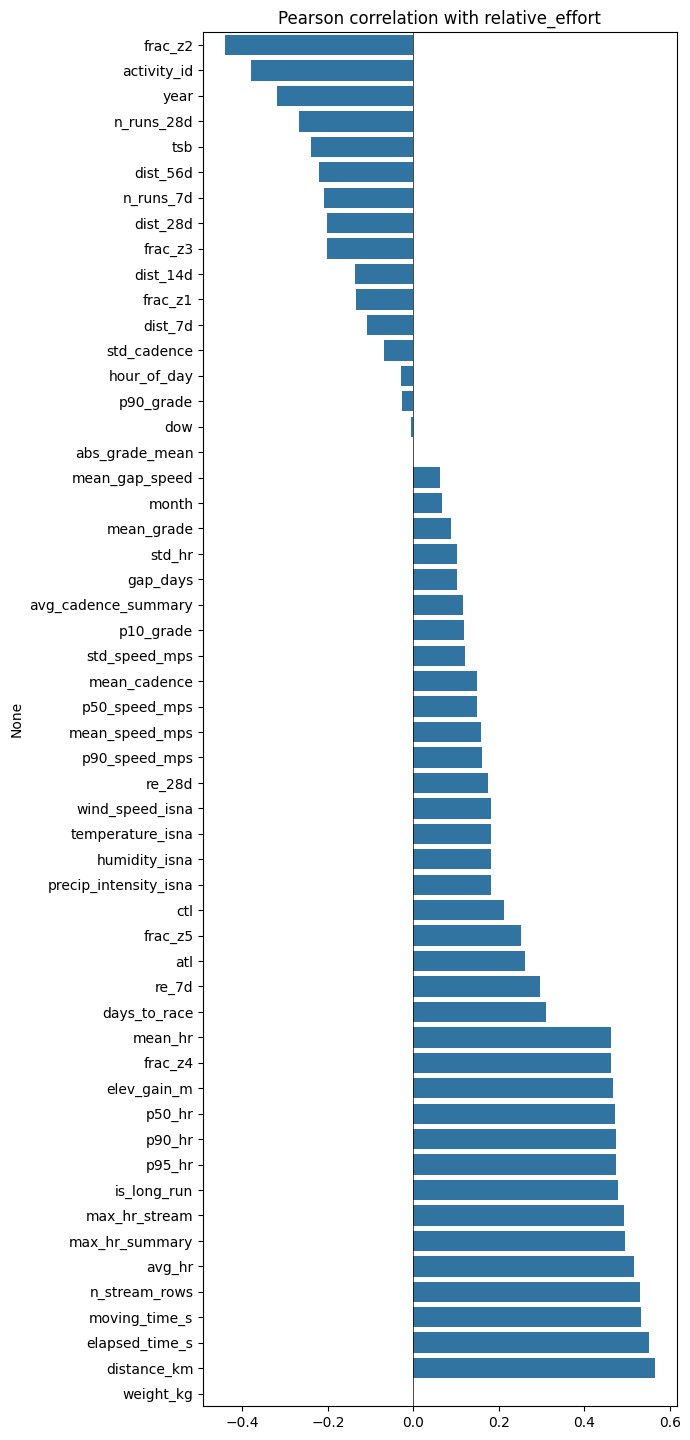

In [7]:
model_table.to_parquet(DATA_DIR / "processed" / "model_table.parquet", index=False)
print("Wrote", DATA_DIR / "processed" / "model_table.parquet")

# Quick smoke check: correlations of numeric features with the target
import matplotlib.pyplot as plt
import seaborn as sns

corr = model_table.select_dtypes(include="number").corr()[target].drop(target).sort_values()
fig, ax = plt.subplots(figsize=(7, 0.25 * len(corr) + 1))
sns.barplot(x=corr.values, y=corr.index, ax=ax, color="tab:blue")
ax.set_title(f"Pearson correlation with {target}")
ax.axvline(0, color="k", linewidth=0.5)
fig.tight_layout()